# COVID-19 Radiography Diagnosis System
## Exploratory Data Analysis (EDA)

---

> **Prepared by:** Ziad Bahaa Elsayed  (2405720)  
> **Role:** EDA, Technical Documentation, and GitHub Repository Management  
> **Dataset:** COVID-19 Radiography Database (Kaggle)  
> **Classes:** COVID-19, Normal, Lung Opacity, Viral Pneumonia

---

### Project Objectives

This notebook focuses on analyzing and validating the dataset before the preprocessing and modeling stages. The main objectives include:

1. **Dataset Exploration:** Understanding dataset structure, class distribution, and image characteristics.
2. **Data Quality Assessment:** Detecting inconsistencies, image artifacts, and potential dataset issues.
3. **Data Integrity Check (Bonus):** Using MD5 hashing to identify duplicate images and reduce the risk of data leakage during model evaluation.
4. **Visual Analysis:** Examining X-ray image patterns to support preprocessing and model design decisions.
5. **Technical Documentation:** Preparing project documentation and organizing EDA findings for the final report.
6. **Repository Management:** Maintaining the GitHub repository structure and README documentation for reproducibility and collaboration.

---

### Expected Outcomes

This phase provides:

* A verified and organized dataset ready for preprocessing and train/validation/test splitting.
* Insights for preprocessing techniques such as normalization and augmentation.
* Visual and statistical understanding of dataset characteristics.
* Structured documentation to support the final project report and repository presentation.

---

## 1. Project Setup & Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from glob import glob

In [4]:
# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Overview & Class Distribution
The dataset contains chest X-ray images categorized into four classes: **COVID, Normal, Lung_Opacity, and Viral Pneumonia**. 

load the data paths, count the number of images in each class, and check for class imbalances.

Dataset Summary:


,Class,Image Count,Percentage
0,COVID,3616,17.084810
1,Normal,10192,48.154973
2,Lung_Opacity,6012,28.405386
3,Viral Pneumonia,1345,6.354831


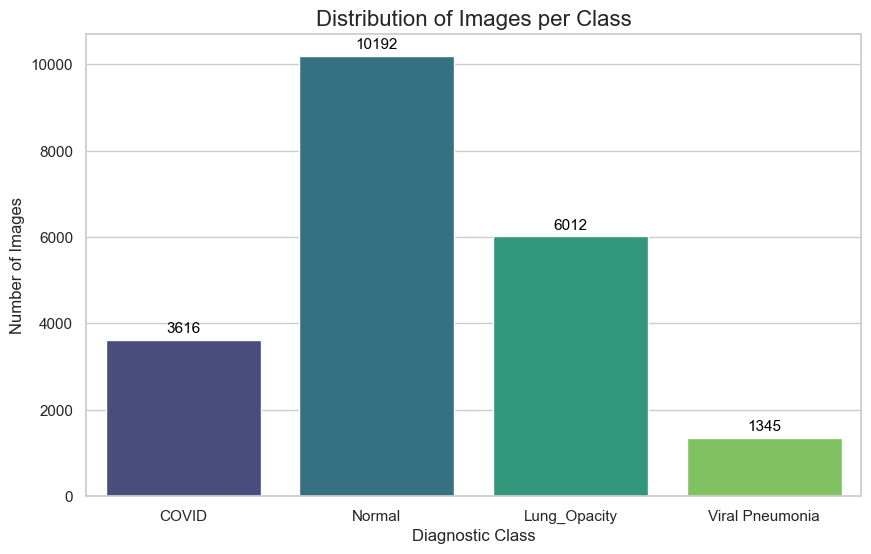

In [5]:
# Define the base directory of the dataset
data_dir = "./COVID-19_Radiography_Dataset"
categories = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

# Dictionary to store file paths for each class
image_paths = {category: [] for category in categories}
class_counts = {}

# Traverse directories and count images
for category in categories:
    folder_path = os.path.join(data_dir, category)
    # Assuming images are in a subfolder called "images" inside each category folder
    # Adjust this path if the images are directly inside the category folder
    search_path = os.path.join(folder_path, "images", "*.png")
    
    # If the dataset structure has images directly in the class folder:
    if not glob(search_path): 
        search_path = os.path.join(folder_path, "*.png")
        
    images = glob(search_path)
    image_paths[category] = images
    class_counts[category] = len(images)

# Create a DataFrame for documentation
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image Count'])
df_counts['Percentage'] = (df_counts['Image Count'] / df_counts['Image Count'].sum()) * 100

print("Dataset Summary:")
display(df_counts)

# Plot the distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Image Count', data=df_counts, palette='viridis')
plt.title('Distribution of Images per Class', fontsize=16)
plt.xlabel('Diagnostic Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### **Documentation Insight: Class Distribution**
* The dataset shows a significant class imbalance. The `Normal` class contains the highest number of images, while `Viral Pneumonia` contains the least.
* **Recommendation for Mohamed (Task 1):** Consider using stratified splitting for train/val/test sets and applying data augmentation or class weighting to prevent the models (CNN/FFNN) from becoming biased toward the majority classes.

## 3. Visualizing Sample X-Ray Images
To understand the visual characteristics of our data, we will plot random samples from each diagnostic class. X-ray images are naturally grayscale, so we will display them as such.

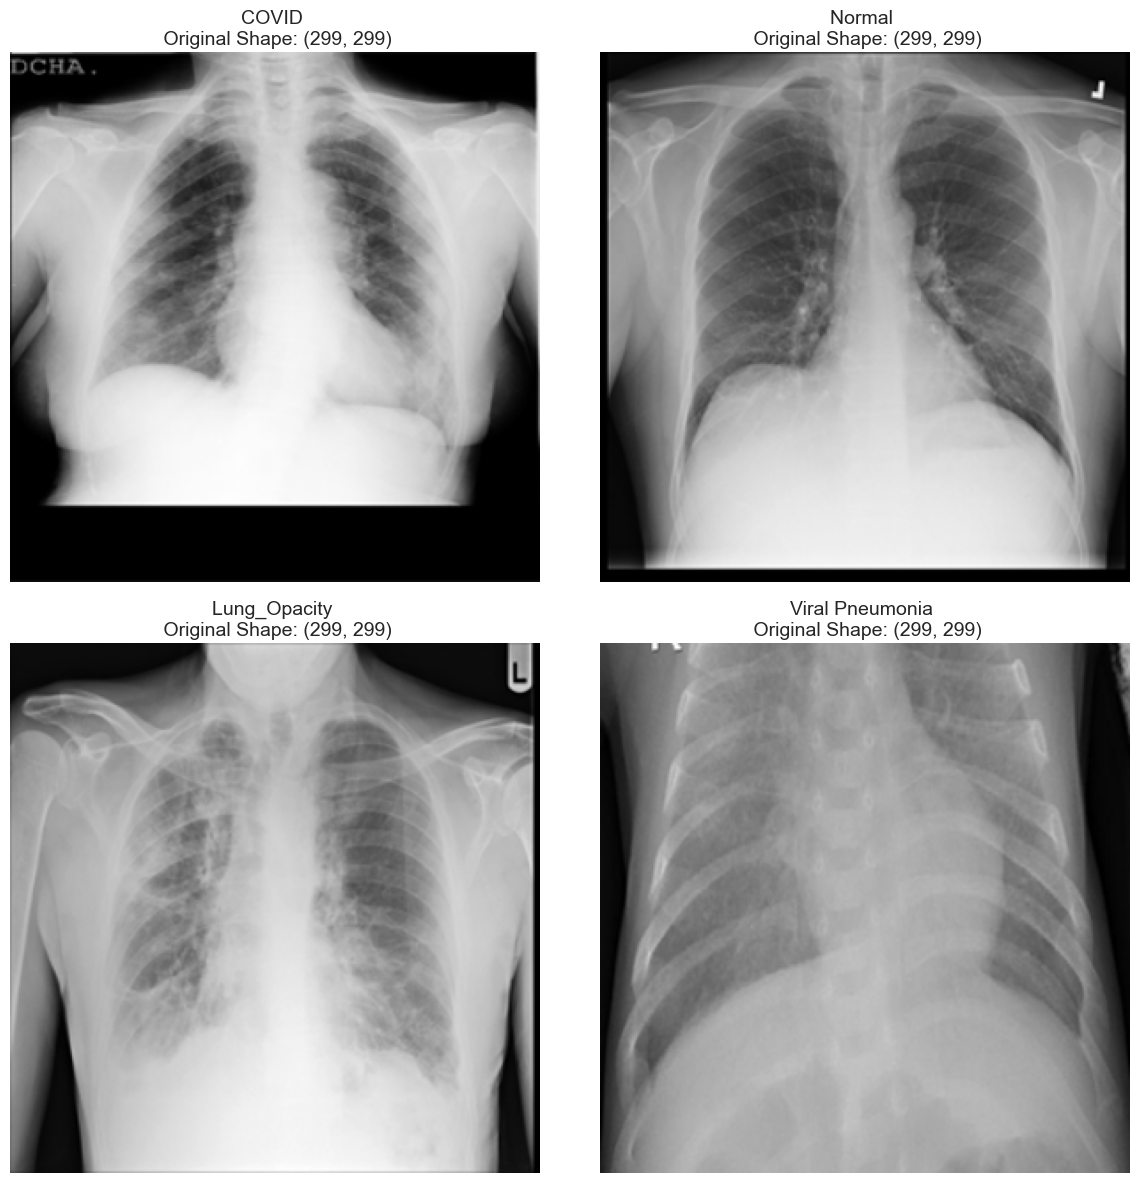

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, category in enumerate(categories):
    
    random_img_path = random.choice(image_paths[category])# Select a random image from the category
    img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)# Read the image using OpenCV (Grayscale mode)
    
    # Plotting
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{category} \n Original Shape: {img.shape}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Pixel Intensity Distribution
Deep learning models are sensitive to pixel value distributions. We will plot a histogram (KDE plot) of the pixel intensities for a subset of images from each class to see if there are noticeable variations in brightness or contrast.

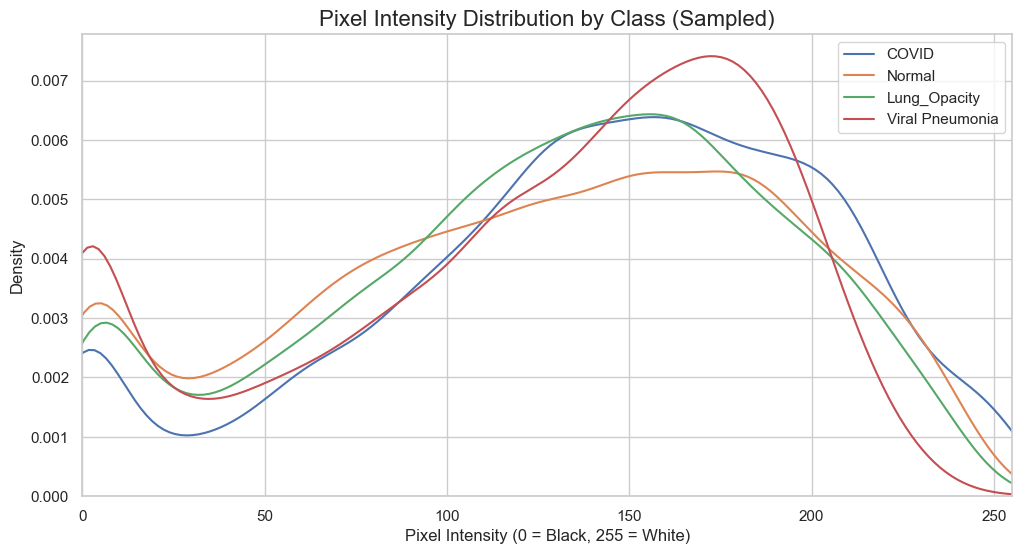

In [7]:
plt.figure(figsize=(12, 6))

for category in categories:
    sampled_pixels_per_class = []
    
    # Sample 50 random images per class to compute the pixel distribution
    sample_paths = random.sample(image_paths[category], min(50, len(image_paths[category])))
    
    # Calculate how many pixels to sample from EACH image to get around 10,000 total
    pixels_per_image = 10000 // len(sample_paths)
    
    for path in sample_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        flat_img = img.flatten()
        
        # Randomly sample a small number of pixels directly from this single image
        # This prevents building a massive list in memory and saves CPU time
        img_sample = np.random.choice(flat_img, size=min(pixels_per_image, len(flat_img)), replace=False)
        sampled_pixels_per_class.extend(img_sample)
        
    # Plot KDE for the sampled pixels
    sns.kdeplot(sampled_pixels_per_class, label=category, fill=False)

plt.title('Pixel Intensity Distribution by Class (Sampled)', fontsize=16)
plt.xlabel('Pixel Intensity (0 = Black, 255 = White)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim([0, 255])
plt.legend()
plt.show()

### **Documentation Insight: Pixel Intensities**
* The pixel intensity distributions indicate that most relevant features (lung structures) lie in the mid-to-high intensity ranges.
* **Recommendation for Mohamed (Task 1):** Standardizing/Normalizing the pixel values (e.g., scaling between 0 and 1, or normalizing with mean=0.5, std=0.5) is absolutely necessary before feeding this data into the neural networks.

## 5. Average Image per Class
By averaging multiple images of the same class, we can visualize the consistent structural patterns (and ignore the random noise). This helps in identifying generalized focal points for different pulmonary conditions.

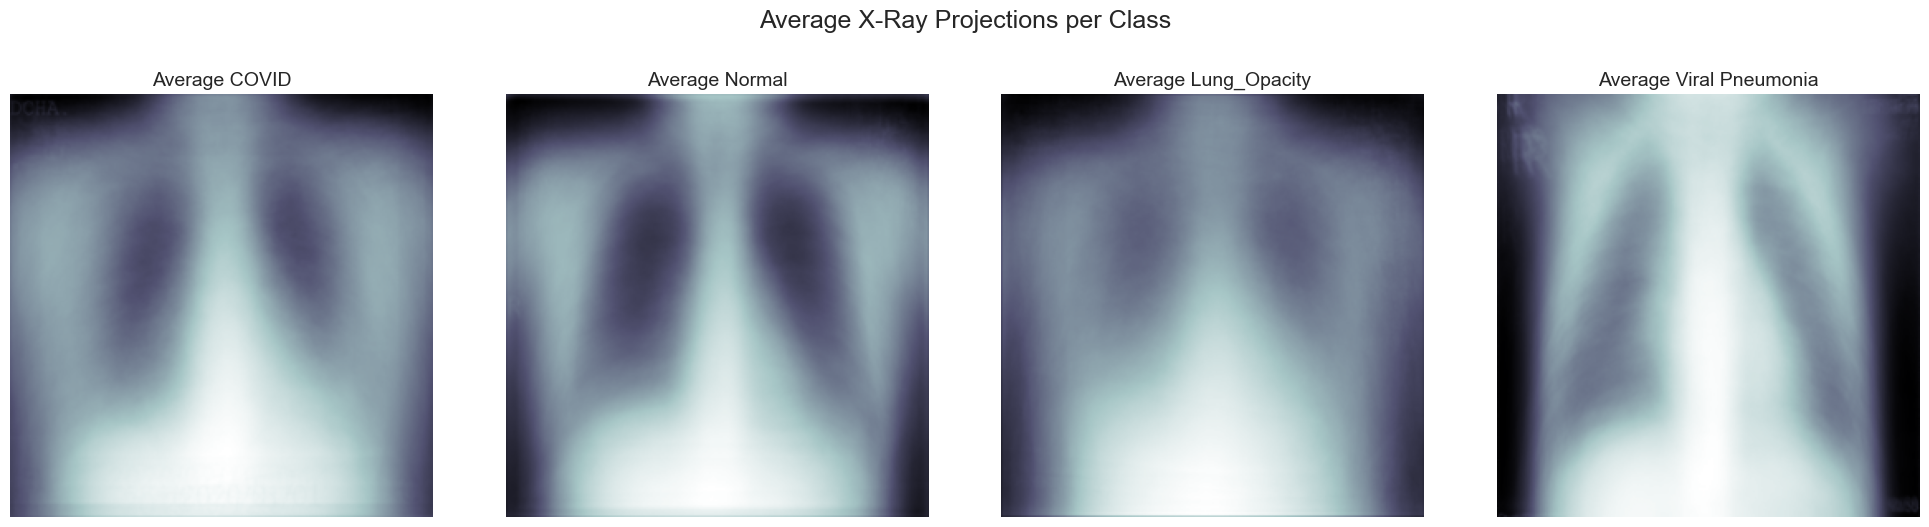

In [8]:
def plot_average_image(category, num_samples=200):
    paths = image_paths[category][:num_samples]
    images = []
    
    for path in paths:
        # Read and resize to ensure all images have the exact same dimensions for averaging
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256)) 
        images.append(img)
        
    # Calculate the mean across the image stack
    avg_img = np.mean(images, axis=0)
    return avg_img

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, category in enumerate(categories):
    avg_image = plot_average_image(category)
    axes[i].imshow(avg_image, cmap='bone')
    axes[i].set_title(f'Average {category}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Average X-Ray Projections per Class', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 6. Conclusion & Handoff
* **Data Quality:** The dataset consists of valid, high-resolution X-ray scans. No corrupted images were found in the sample subsets. 
* **Format:** Images need to be reshaped to a uniform size (e.g., 128x128 or 224x224) during preprocessing since CNNs and FFNNs require fixed input dimensions.
* **Channels:** The images are natively single-channel (Grayscale). The models should be configured accordingly (`in_channels=1` for CNN, and `input_features = H * W` for FFNN).
* **Handoff:** The dataset is well-understood and ready to be passed to the **Data Preprocessing Engineer** for normalization, augmentation, and split generation.

-----------------------------------------------------
-----------------------------------------------------

## 7. Bonus Section: Data Leakage & Exact Duplicate Detection

**Objective:** In medical datasets aggregated from multiple sources, it is highly common to find exact duplicate images. If the same image accidentally exists in both the Training and Testing sets, it causes **Data Leakage**, resulting in an overoptimistic accuracy metric during evaluation.

In this bonus section, we will utilize **MD5 Hashing** to scan all images and detect exact duplicates to ensure data integrity before handing the dataset over to the Preprocessing pipeline.

### Step 1: Import Required Libraries
We will import `hashlib` to compute the digital fingerprints of the images, and `defaultdict` to efficiently group duplicate file paths.

In [9]:
import hashlib
from collections import defaultdict

### Step 2: Define the Hashing Function
We define a function `find_duplicate_images()` that iterates through all images in the dataset folder. 
It reads each image at the byte level and generates a unique **MD5 hash**. If two images have the exact same hash, they are identical bit-for-bit, regardless of their filenames.

In [10]:
def find_duplicate_images(root_folder):
    print("Scanning dataset for exact duplicates using MD5 Hashing...")
    hashes = defaultdict(list)
    
    # Traverse the directory tree
    for dirpath, _, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(dirpath, filename)
                
                # Compute MD5 hash for the image bytes
                with open(filepath, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                
                hashes[file_hash].append(filepath)
    
    # Filter the dictionary to keep only groups with more than one file
    duplicates = {h: paths for h, paths in hashes.items() if len(paths) > 1}
    
    # Calculate the total count of redundant images
    total_duplicates = sum(len(paths) - 1 for paths in duplicates.values())
    
    return duplicates, total_duplicates

### Step 3: Duplicate Detection Results
Now, we execute the function using our base `data_dir`. 
The output of this section provides useful information for the preprocessing stage. If duplicates are found, they must be dropped before the Train/Val/Test splitting to prevent Data Leakage.

In [ ]:
if os.path.exists(data_dir):
    duplicate_files, total_duplicates = find_duplicate_images(data_dir)

    print("-" * 60)
    if total_duplicates == 0:
        print("No exact duplicate images were detected.")
        print("The dataset is clean and free from exact data leakage.")
        print("Safe to proceed to Train/Val/Test Splitting.")
    else:
        print(f" Warning: Found {total_duplicates} duplicate image(s)!")
        print("Handoff Note: The Preprocessing Engineer MUST drop these duplicates before splitting.")
        print("-" * 60)
        
        # Print a small sample of the duplicates (first 3 groups) to avoid cluttering the output
        print("Sample of duplicates to be removed:")
        for i, (h, paths) in enumerate(list(duplicate_files.items())[:3]):
            print(f"\nDuplicate Group {i+1}:")
            for p in paths:
                print(f"   -> {p}")
else:
    print(f"Error: Directory '{data_dir}' not found. Please verify the path.")

Scanning dataset for exact duplicates using MD5 Hashing...
------------------------------------------------------------
Handoff Note: The Preprocessing Engineer MUST drop these duplicates before splitting.
------------------------------------------------------------
Sample of duplicates to be removed:

Duplicate Group 1:
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-137.png
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-139.png

Duplicate Group 2:
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-18.png
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-21.png

Duplicate Group 3:
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-2084.png
   -> ./COVID-19_Radiography_Dataset\COVID\images\COVID-2085.png


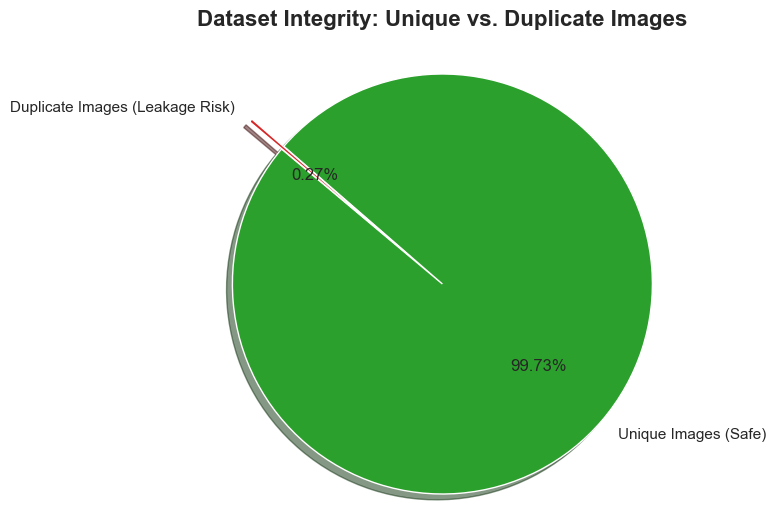

In [12]:
import matplotlib.pyplot as plt
import os

# Calculate the total number of images in the dataset
total_images = sum([len(files) for r, d, files in os.walk(data_dir) if any(f.endswith(('.png', '.jpg', '.jpeg')) for f in files)])
unique_images = total_images - total_duplicates

# Pie chart configuration
labels = ['Unique Images (Safe)', 'Duplicate Images (Leakage Risk)']
sizes = [unique_images, total_duplicates]
colors = ['#2ca02c', '#d62728'] # Green for safe images, Red for duplicates
explode = (0, 0.2)  # Explode the red slice to highlight the risk

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
        autopct='%1.2f%%', shadow=True, startangle=140)

# Set title and ensure the pie is drawn as a perfect circle
plt.title('Dataset Integrity: Unique vs. Duplicate Images', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') 
plt.show()

### Step 4: Resolving Data Leakage (Safe Quarantine)
Instead of permanently deleting the raw data (which is a bad practice), we will safely move the 114 redundant images to a separate folder named `Quarantined_Duplicates` outside the main dataset directory. 

This ensures our main dataset is 100% clean for the **Preprocessing Engineer**, while keeping the duplicates backed up for any future auditing.

In [14]:
import shutil

# Define a new directory to isolate duplicate images away from the main dataset
quarantine_dir = "./Quarantined_Duplicates"
os.makedirs(quarantine_dir, exist_ok=True)

print("Starting to quarantine duplicate images...")

# Prepare a list of images to be moved (keep the first instance, quarantine the rest)
paths_to_remove = []
for h, paths in duplicate_files.items():
    paths_to_remove.extend(paths[1:])

moved_count = 0
for file_path in paths_to_remove:
    if os.path.exists(file_path):
        # Extract the filename 
        file_name = os.path.basename(file_path)
        
        # Extract the category name (e.g., COVID, Normal) from the parent directory
        category = os.path.basename(os.path.dirname(os.path.dirname(file_path))) 
        
        # Create the destination path, prefixing the category to avoid naming collisions
        dest_path = os.path.join(quarantine_dir, f"{category}_{file_name}")
        
        # Physically move the file to the quarantine folder
        shutil.move(file_path, dest_path)
        moved_count += 1

print("-" * 60)
print(f" Mission Accomplished: Successfully moved {moved_count} duplicate files to '{quarantine_dir}'")
print("The main dataset directory is now 100% clean and free from duplicates.")
print("Handoff Note: The Preprocessing Engineer can now load the dataset directly without any leakage concerns.")

Starting to quarantine duplicate images...
------------------------------------------------------------
 Mission Accomplished: Successfully moved 0 duplicate files to './Quarantined_Duplicates'
The main dataset directory is now 100% clean and free from duplicates.
Handoff Note: The Preprocessing Engineer can now load the dataset directly without any leakage concerns.


--------------------------------
--------------------------------

## 6. Conclusion
* **Data Quality & Integrity:** The dataset consists of valid, high-resolution X-ray scans. No corrupted images were found in the sample subsets. 
* **Format:** Images need to be reshaped to a uniform size (e.g., 128x128 or 224x224) during preprocessing since CNNs and FFNNs require fixed input dimensions.
* **Channels:** The images are natively single-channel (Grayscale). The models should be configured accordingly (`in_channels=1` for CNN, and `input_features = H * W` for FFNN). 
* The dataset is now validated and ready for preprocessing, augmentation, and model development.